Imports

In [125]:
import matplotlib.pyplot as plt
import pandas as pd 
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

In [126]:
df = pd.read_csv('../dataset/training_data_processed.csv')
df = df.drop(columns=['affirmative_questions', 'evasion_label'])

df.head

<bound method NDFrame.head of       Unnamed: 0  question_order  \
0              0               1   
1              1               1   
2              2               2   
3              3               2   
4              4               3   
...          ...             ...   
3443        3443              16   
3444        3444              17   
3445        3445              18   
3446        3446              18   
3447        3447              19   

                                     interview_question  \
0     Q. Of the Biden administration. And accused th...   
1     Q. Of the Biden administration. And accused th...   
2     Q. No worries. Do you believe the country's sl...   
3     Q. No worries. Do you believe the country's sl...   
4     Q. I can imagine. It is evening, I'd like to r...   
...                                                 ...   
3443  Q. Thank you, Mr. President. With a Republican...   
3444  Q. I just wanted to ask you quickly, sir, if y...   
3445  

New columns

In [127]:
df = pd.read_csv('../dataset/training_data_processed.csv')
df = df.drop(columns=['gpt3.5_summary','gpt3.5_prediction'])
print(df.head)

<bound method NDFrame.head of       Unnamed: 0  question_order  \
0              0               1   
1              1               1   
2              2               2   
3              3               2   
4              4               3   
...          ...             ...   
3443        3443              16   
3444        3444              17   
3445        3445              18   
3446        3446              18   
3447        3447              19   

                                     interview_question  \
0     Q. Of the Biden administration. And accused th...   
1     Q. Of the Biden administration. And accused th...   
2     Q. No worries. Do you believe the country's sl...   
3     Q. No worries. Do you believe the country's sl...   
4     Q. I can imagine. It is evening, I'd like to r...   
...                                                 ...   
3443  Q. Thank you, Mr. President. With a Republican...   
3444  Q. I just wanted to ask you quickly, sir, if y...   
3445  

Tokenization and padding

In [128]:

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text_columns = ['interview_answer', 'question']

df_text = df[text_columns]

df_text['AllText'] = df_text['interview_answer'] + '' + df_text['question']

df_text['Tokenized_answer'] = df_text['interview_answer'].apply(
    lambda x: tokenizer(
        str(x),
        truncation=True,
        max_length=256,  
        padding='max_length',  
        return_tensors='pt'
    )['input_ids'].squeeze()
)
df_text['Tokenized_question'] = df_text['question'].apply(
    lambda x: tokenizer(
        str(x),
        truncation=True,
        max_length=256,
        padding='max_length',  
        return_tensors='pt'
    )['input_ids'].squeeze()
)


df_text['Tokenized_text'] = df_text['Tokenized_answer'] + df_text['Tokenized_question']


/var/folders/cv/c57lwln12h1c9cflgwf4bn680000gn/T/ipykernel_2789/128600964.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_text['AllText'] = df_text['interview_answer'] + '' + df_text['question']
/var/folders/cv/c57lwln12h1c9cflgwf4bn680000gn/T/ipykernel_2789/128600964.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_text['Tokenized_answer'] = df_text['interview_answer'].apply(
/var/folders/cv/c57lwln12h1c9cflgwf4bn680000gn/T/ipykernel_2789/128600964.py:17: SettingWithCopyWarning: 
A value is tr

Mapping the labels

In [129]:
mappings = {'Ambivalent': 0, 'Clear Reply': 1, 'Clear Non-Reply': 2}


df['clarity_label'] = df['clarity_label'].map(mappings)

training_data = pd.DataFrame({
    'label': df['clarity_label'],                
    'question': df_text['Tokenized_question'],   
    'answer': df_text['Tokenized_answer']      
})

X_questions = torch.stack(training_data['question'].tolist()) 
X_answers = torch.stack(training_data['answer'].tolist())      
y = torch.tensor(training_data['label'].values, dtype=torch.long)

print(f"X_questions shape: {X_questions.shape}")  
print(f"X_answers shape: {X_answers.shape}")    
print(f"y shape: {y.shape}")  
print("\nClass distribution:")
print("\nClass counts from tensor:")
unique, counts = torch.unique(y, return_counts=True)
for class_idx, count in zip(unique, counts):
    class_name = [k for k, v in mappings.items() if v == class_idx][0]
    print(f"Class {class_idx} ({class_name}): {count}")



X_questions shape: torch.Size([3448, 256])
X_answers shape: torch.Size([3448, 256])
y shape: torch.Size([3448])

Class distribution:

Class counts from tensor:
Class 0 (Ambivalent): 2040
Class 1 (Clear Reply): 1052
Class 2 (Clear Non-Reply): 356


Splitting teh data upp for train and testing

In [130]:
X_q_train, X_q_test, X_a_train, X_a_test, y_train, y_test = train_test_split(
    X_questions, X_answers, y, test_size=0.2, random_state=42, stratify=y
)

print("\nClass counts from tensor:")
unique, counts = torch.unique(y_train, return_counts=True)
for class_idx, count in zip(unique, counts):
    class_name = [k for k, v in mappings.items() if v == class_idx][0]
    print(f"Class {class_idx} ({class_name}): {count}")


print(f'Number of samples when stratified: {X_q_train.shape}')
print(f'Number of test samples when straified: {X_q_test.shape}')


Class counts from tensor:
Class 0 (Ambivalent): 1632
Class 1 (Clear Reply): 841
Class 2 (Clear Non-Reply): 285
Number of samples when stratified: torch.Size([2758, 256])
Number of test samples when straified: torch.Size([690, 256])


Full oversampling

In [131]:
from collections import Counter
import numpy as np

def full_oversample(X_q, X_a, y):
    class_counts = Counter(y.numpy())
    max_count = max(class_counts.values())
    
    X_q_balanced = []
    X_a_balanced = []
    y_balanced = []
    
    for class_label in sorted(class_counts.keys()):
        class_mask = (y == class_label)
        X_q_class = X_q[class_mask]
        X_a_class = X_a[class_mask]
        y_class = y[class_mask]
        
        current_count = len(y_class)
        
        # Oversample to match max_count
        if current_count < max_count:
            indices = np.random.choice(current_count, max_count - current_count, replace=True)
            X_q_balanced.append(torch.cat([X_q_class, X_q_class[indices]]))
            X_a_balanced.append(torch.cat([X_a_class, X_a_class[indices]]))
            y_balanced.append(torch.cat([y_class, y_class[indices]]))
        else:
            X_q_balanced.append(X_q_class)
            X_a_balanced.append(X_a_class)
            y_balanced.append(y_class)
    
    return (torch.cat(X_q_balanced), 
            torch.cat(X_a_balanced),
            torch.cat(y_balanced))

Partial oversampling

In [132]:
def partial_oversample(X_q, X_a, y, target_ratio):
    class_counts = Counter(y.numpy())
    majority_count = max(class_counts.values())
    
    X_q_balanced = []
    X_a_balanced = []
    y_balanced = []
    
    for class_label in sorted(class_counts.keys()):
        class_mask = (y == class_label)
        X_q_class = X_q[class_mask]
        X_a_class = X_a[class_mask]
        y_class = y[class_mask]
        
        current_count = len(y_class)
        target_count = int(majority_count * target_ratio)
        
        if current_count < target_count:
            n_samples_needed = target_count - current_count
            indices = np.random.choice(current_count, n_samples_needed, replace=True)
            X_q_balanced.append(torch.cat([X_q_class, X_q_class[indices]]))
            X_a_balanced.append(torch.cat([X_a_class, X_a_class[indices]]))
            y_balanced.append(torch.cat([y_class, y_class[indices]]))
        else:
            X_q_balanced.append(X_q_class)
            X_a_balanced.append(X_a_class)
            y_balanced.append(y_class)
    
    return (torch.cat(X_q_balanced), 
            torch.cat(X_a_balanced), 
            torch.cat(y_balanced))


Full undersampling

In [133]:
def full_undersample(X_q, X_a, y):

    class_counts = Counter(y.numpy())
    min_count = min(class_counts.values())
    
    target_counts = {c: min_count for c in class_counts.keys()}
    
    X_q_sampled = []
    X_a_sampled = []
    y_sampled = []
    
    for class_label in sorted(class_counts.keys()):
        class_mask = (y == class_label)
        X_q_class = X_q[class_mask]
        X_a_class = X_a[class_mask]
        y_class = y[class_mask]
        
        current_count = len(y_class)
        target_count = target_counts[class_label]
        
        if current_count > target_count:
           
            indices = np.random.choice(current_count, target_count, replace=False)
            X_q_sampled.append(X_q_class[indices])
            X_a_sampled.append(X_a_class[indices])
            y_sampled.append(y_class[indices])
        else:
        
            X_q_sampled.append(X_q_class)
            X_a_sampled.append(X_a_class)
            y_sampled.append(y_class)
    
    X_q_result = torch.cat(X_q_sampled)
    X_a_result = torch.cat(X_a_sampled)
    y_result = torch.cat(y_sampled)

    indices = torch.randperm(len(y_result))
    
    
    return X_q_result[indices], X_a_result[indices], y_result[indices]



Partial undersampling

In [138]:

def undersample_with_ratio(X_q, X_a, y, minority_ratio=1.7):

    class_counts = Counter(y.numpy())
    min_count = min(class_counts.values())
    target_count = int(min_count * minority_ratio)
    
    X_q_sampled = []
    X_a_sampled = []
    y_sampled = []
    
    for class_label in sorted(class_counts.keys()):
        class_mask = (y == class_label)
        X_q_class = X_q[class_mask]
        X_a_class = X_a[class_mask]
        y_class = y[class_mask]
        
        current_count = len(y_class)
        
        if current_count > target_count:
            
            indices = np.random.choice(current_count, target_count, replace=False)
            X_q_sampled.append(X_q_class[indices])
            X_a_sampled.append(X_a_class[indices])
            y_sampled.append(y_class[indices])
        else:
         
            X_q_sampled.append(X_q_class)
            X_a_sampled.append(X_a_class)
            y_sampled.append(y_class)
    
    X_q_result = torch.cat(X_q_sampled)
    X_a_result = torch.cat(X_a_sampled)
    y_result = torch.cat(y_sampled)
    
 
    indices = torch.randperm(len(y_result))
    

    
    return X_q_result[indices], X_a_result[indices], y_result[indices]

Coverting it to Tensordataset adn specifying a loader

In [139]:
X_a_train, X_q_train, y_train = undersample_with_ratio(X_a_train, X_q_train, y_train)
batch_size = 32
train_dataset = TensorDataset(X_a_train, X_q_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size)

GRU model

In [140]:
# Model configuration
max_length = 256
embedding_dim = 64  
hidden_units = 64
n_layers = 2
vocab_size = tokenizer.vocab_size

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_units, n_layers, output_dim=3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding_dropout = nn.Dropout(0.2)
        
        #
        self.question_gru = nn.GRU(
            embedding_dim, hidden_units, n_layers,
            batch_first=True, bidirectional=True, dropout=0)
        
        self.answer_gru = nn.GRU(
            embedding_dim, hidden_units, n_layers,
            batch_first=True, bidirectional=True, dropout=0.2
        )
        
    
        self.attention = nn.Linear(hidden_units * 2, 1)
        
        self.dropout = nn.Dropout(0.2)
        
      
        self.fc = nn.Linear(hidden_units * 4, output_dim)

    def forward(self, questions, answers):
        
        q_embedded = self.embedding_dropout(self.embedding(questions))
        a_embedded = self.embedding_dropout(self.embedding(answers))
        
        
        q_out, _ = self.question_gru(q_embedded)
        a_out, _ = self.answer_gru(a_embedded)
        
        
        attention_weights = F.softmax(self.attention(a_out), dim=1)
        a_attended = torch.sum(attention_weights * a_out, dim=1)
        
        
        q_final = q_out[:, -1, :]
        
        combined = torch.cat([q_final, a_attended], dim=1)
        
        combined = self.dropout(combined)
        out = self.fc(combined)
        out = F.log_softmax(out, dim=1)
        return out


model = GRUModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_units=hidden_units,
    n_layers=n_layers,
    output_dim=3
)


class_weights = torch.tensor([1.0, 1.0, 1.0])

loss_fn = nn.NLLLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

Training the model

In [ ]:
def train(model, loader, optimizer, loss_fn, epochs):
    for epoch in range(epochs):
        print(f'Nr: {epoch + 1}')
        total_loss = 0
        correct = 0
        total = 0
        class_correct = torch.zeros(3)
        class_total = torch.zeros(3)
        
        for X_q_batch, X_a_batch, y_batch in loader: 
            optimizer.zero_grad()
            
            log_probs = model(X_q_batch, X_a_batch)
            loss = loss_fn(log_probs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(log_probs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            for c in range(3):
                mask = y_batch == c
                class_total[c] += mask.sum().item()
                class_correct[c] += (predicted[mask] == y_batch[mask]).sum().item()
        
        accuracy = 100 * correct / total
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.2f}%")
        
        print(" Per-class accuracy:")
        for c in range(3):
            if class_total[c] > 0:
                class_acc = 100 * class_correct[c] / class_total[c]
                print(f" Class {c}: {class_acc:.2f}% (n={int(class_total[c])})")
            else:
                print(f" Class {c}: No samples")
        print() 
    
    return model

num_epochs = 20
trained_model = train(model, train_loader, optimizer, loss_fn, num_epochs)



Nr: 1
Epoch 1/20 - Loss: 1.0761 - Accuracy: 37.27%
 Per-class accuracy:
 Class 0: 41.32% (n=484)
 Class 1: 45.04% (n=484)
 Class 2: 17.19% (n=285)

Nr: 2
Epoch 2/20 - Loss: 1.0491 - Accuracy: 37.83%
 Per-class accuracy:
 Class 0: 35.74% (n=484)
 Class 1: 54.75% (n=484)
 Class 2: 12.63% (n=285)

Nr: 3
Epoch 3/20 - Loss: 1.0454 - Accuracy: 39.43%
 Per-class accuracy:
 Class 0: 34.92% (n=484)
 Class 1: 57.02% (n=484)
 Class 2: 17.19% (n=285)

Nr: 4
Epoch 4/20 - Loss: 1.0386 - Accuracy: 40.06%
 Per-class accuracy:
 Class 0: 37.81% (n=484)
 Class 1: 53.10% (n=484)
 Class 2: 21.75% (n=285)

Nr: 5
Epoch 5/20 - Loss: 1.0253 - Accuracy: 42.86%
 Per-class accuracy:
 Class 0: 40.91% (n=484)
 Class 1: 52.89% (n=484)
 Class 2: 29.12% (n=285)

Nr: 6
Epoch 6/20 - Loss: 0.9975 - Accuracy: 45.97%
 Per-class accuracy:
 Class 0: 44.63% (n=484)
 Class 1: 52.07% (n=484)
 Class 2: 37.89% (n=285)

Nr: 7
Epoch 7/20 - Loss: 0.9641 - Accuracy: 49.64%
 Per-class accuracy:
 Class 0: 48.35% (n=484)
 Class 1: 52.27

Printing model parameters

In [ ]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
GRUModel                                 --
├─Embedding: 1-1                         1,953,408
├─Dropout: 1-2                           --
├─GRU: 1-3                               124,416
├─GRU: 1-4                               124,416
├─Linear: 1-5                            129
├─Dropout: 1-6                           --
├─Linear: 1-7                            771
Total params: 2,203,140
Trainable params: 2,203,140
Non-trainable params: 0

Testing and visualisation

Test Accuracy: 28.99%
Weighted F1-Score: 33.10


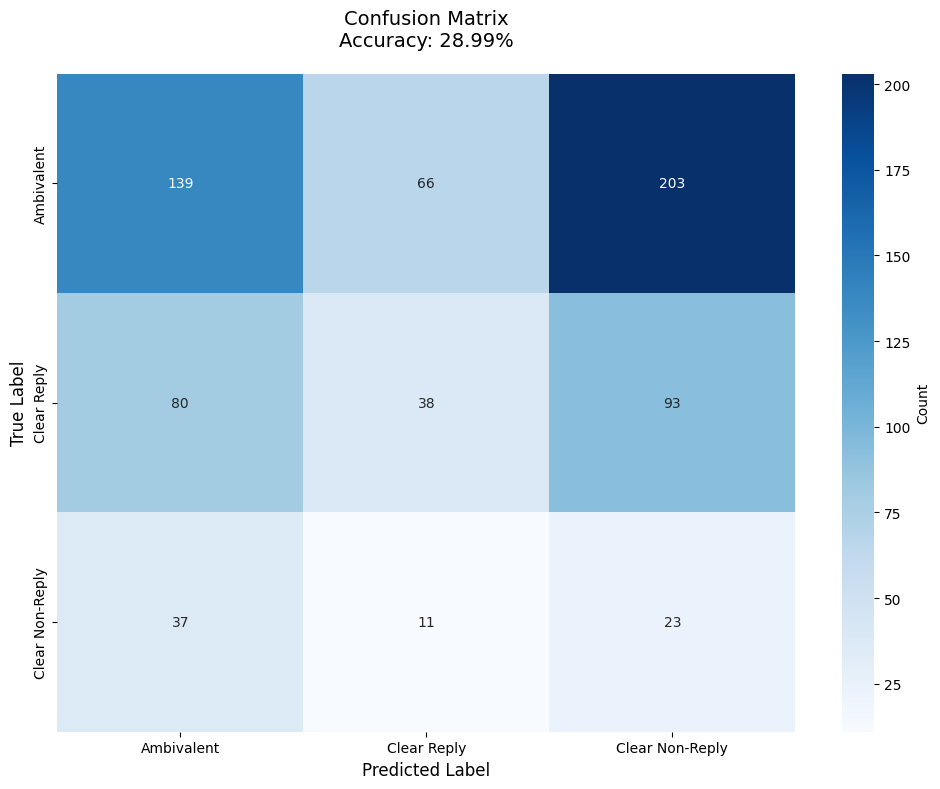

In [ ]:
def evaluate(model, X_q_test, X_a_test, y_test, batch_size=32):
    model.eval()
    test_dataset = TensorDataset(X_q_test, X_a_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    correct = 0
    total = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for X_q_batch, X_a_batch, y_batch in test_loader:
            log_probs = model(X_q_batch, X_a_batch)
            _, predicted = torch.max(log_probs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    weighted_f1 = f1_score(all_labels, all_predictions, average='weighted') * 100
    print(f"Weighted F1-Score: {weighted_f1:.2f}")
    
    cm = confusion_matrix(y_true=all_labels, y_pred=all_predictions)
    
    plt.figure(figsize=(10, 8))
    
    class_names = ['Ambivalent', 'Clear Reply', 'Clear Non-Reply']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    
    plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.2f}%', fontsize=14, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return accuracy, cm

accuracy, confusion_mat = evaluate(trained_model, X_q_test, X_a_test, y_test)

 